In [1]:
!pip install scikit-image opencv-python-headless matplotlib numpy Pillow -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters import threshold_sauvola
import os, json, time, zipfile, shutil
from pathlib import Path
from google.colab import files

print('✅ Libraries loaded')
print(f'OpenCV: {cv2.__version__}')

✅ Libraries loaded
OpenCV: 4.13.0


In [2]:
# Clone the repo
!git clone --depth=1 https://github.com/tanmayGIT/DIBCO_2019_All.git 2>/dev/null || echo 'Already cloned'

# Inspect folder structure
import os
for root, dirs, files_list in os.walk('DIBCO_2019_All'):
    depth = root.replace('DIBCO_2019_All', '').count(os.sep)
    if depth < 4:
        indent = '  ' * depth
        print(f'{indent}📁 {os.path.basename(root)}/')
        if depth == 3:
            for f in sorted(files_list)[:5]:
                print(f'{indent}  📄 {f}')
            if len(files_list) > 5:
                print(f'{indent}  ... and {len(files_list)-5} more files')

📁 DIBCO_2019_All/
  📁 Matlab_Code/
  📁 DIBCO_2019_Work/
    📁 All_Images_DIBCO_2019/
    📁 DIBCO_2019_Dataset_1st_part/
      📁 ground_truth_tif/
        📄 P.CtYBR inv. 69.tif
        📄 P.Mich.inv.2755.tif
        📄 P.Oxy.XXII 2309.tif
        📄 PSI XII 1274 r.xcf.tif
        📄 PSI XIV 1376 r.tif
      📁 original/
        📄 P.CtYBR inv. 69.jpg
        📄 P.Mich.inv.2755.jpg
        📄 P.Oxy.XXII 2309.jpg
        📄 PSI XII 1274 r.jpg
        📄 PSI XIV 1376 r.jpg
      📁 ground_truth_png/
        📄 P.CtYBR inv. 69.png
        📄 P.Mich.inv.2755.png
        📄 P.Oxy.XXII 2309.png
        📄 PSI XII 1274 r.xcf.png
        📄 PSI XIV 1376 r.png
    📁 Result_Img_Dataset_2/
    📁 LCM_binarisation_v1/
    📁 OrigImgDataset_2/
    📁 Document_Binarization_SSP/
      📁 DocumentBinary_SSP_EXE_v1.1/
        📄 Bin_ICDAR_2019.bat
        📄 DIA_Bin.dll
        📄 DocumentBinary_SSP.exe
        📄 PR5.bmp
        📄 PR5_bin.bmp
        ... and 12 more files
    📁 BinImages/
      📁 niblack/
        📄 P. Laur. IV

In [3]:
# Automatically detect dataset paths
BASE = 'DIBCO_2019_All/DIBCO_2019_Work'

# Find original images and ground truth folders
IMG_DIR = None
GT_DIR  = None

for root, dirs, flist in os.walk(BASE):
    for d in dirs:
        full = os.path.join(root, d)
        if 'original' in d.lower() or 'All_Images' in d:
            IMG_DIR = full
        if 'ground_truth' in d.lower() and 'png' in d.lower():
            GT_DIR = full

# Manual fallback — write here if the folder name has changed
if IMG_DIR is None:
    IMG_DIR = 'DIBCO_2019_All/DIBCO_2019_Work/All_Images_DIBCO_2019'
if GT_DIR is None:
    GT_DIR  = 'DIBCO_2019_All/DIBCO_2019_Work/All_GT_DIBCO_2019'

print(f'📂 Image folder : {IMG_DIR}')
print(f'📂 Ground truth : {GT_DIR}')

# Find matching file pairs
def find_pairs(img_dir, gt_dir):
    """Match image and GT files by name."""
    pairs = []
    if not os.path.exists(img_dir) or not os.path.exists(gt_dir):
        print('⚠️  Folder not found! Fix the path below.')
        return pairs
    img_files = {Path(f).stem: f for f in os.listdir(img_dir)
                 if f.lower().endswith(('.png','.jpg','.bmp','.tif'))}
    gt_files  = {Path(f).stem: f for f in os.listdir(gt_dir)
                 if f.lower().endswith(('.png','.jpg','.bmp','.tif'))}
    for stem in sorted(img_files):
        if stem in gt_files:
            pairs.append({
                'name': stem,
                'img': os.path.join(img_dir, img_files[stem]),
                'gt':  os.path.join(gt_dir,  gt_files[stem]),
            })
    return pairs

PAIRS = find_pairs(IMG_DIR, GT_DIR)
print(f'\n✅ {len(PAIRS)} image pairs found:')
for p in PAIRS:
    print(f'   • {p["name"]}')

📂 Image folder : DIBCO_2019_All/DIBCO_2019_Work/DIBCO_2019_Dataset_1st_part/original
📂 Ground truth : DIBCO_2019_All/DIBCO_2019_Work/DIBCO_2019_Dataset_1st_part/ground_truth_png

✅ 4 image pairs found:
   • P.CtYBR inv. 69
   • P.Mich.inv.2755
   • P.Oxy.XXII 2309
   • PSI XIV 1376 r


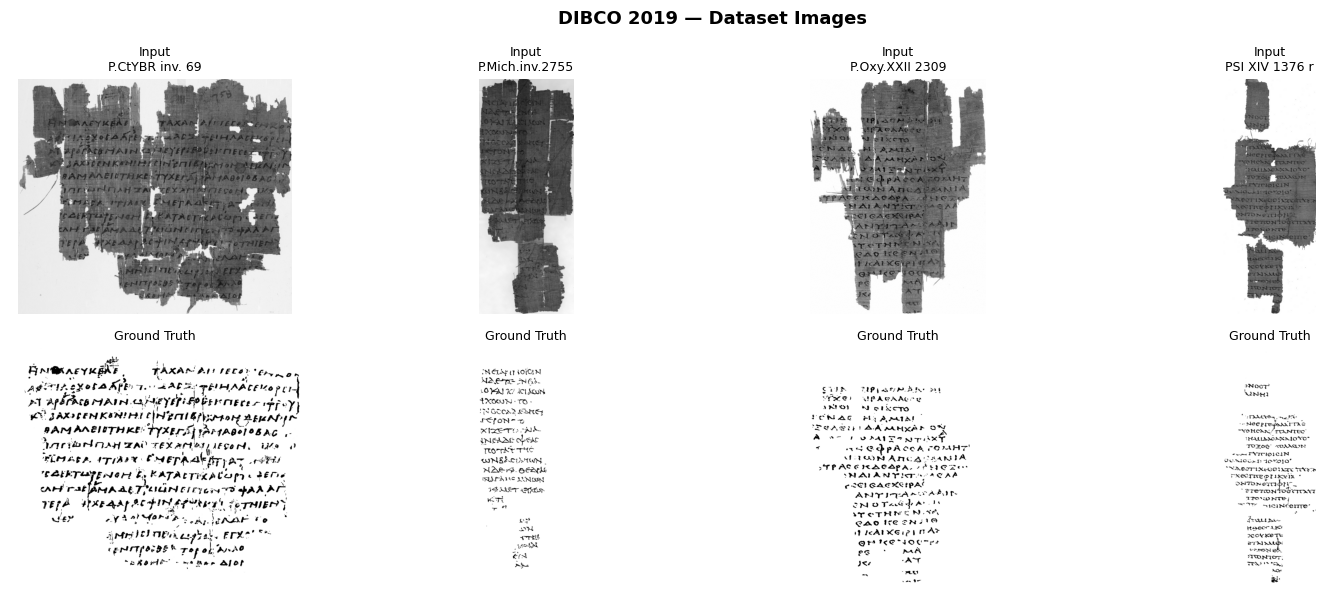

✅ fig1_dataset_samples.png saved


In [4]:
# ── If no pairs found, fix the path manually here ──────────────────
# IMG_DIR = 'DIBCO_2019_All/DIBCO_2019_Work/CORRECT_FOLDER_HERE'
# GT_DIR  = 'DIBCO_2019_All/DIBCO_2019_Work/CORRECT_GT_FOLDER_HERE'
# PAIRS   = find_pairs(IMG_DIR, GT_DIR)
# ──────────────────────────────────────────────────────────────────────

# Show sample images
n_show = len(PAIRS)
if n_show > 0:
    fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 6))
    if n_show == 1:
        axes = np.expand_dims(axes, axis=1)
    for i, p in enumerate(PAIRS[:n_show]):
        img = cv2.imread(p['img'], cv2.IMREAD_GRAYSCALE)
        gt  = cv2.imread(p['gt'],  cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Input\n{p["name"]}', fontsize=9)
        axes[0, i].axis('off')
        axes[1, i].imshow(gt, cmap='gray')
        axes[1, i].set_title('Ground Truth', fontsize=9)
        axes[1, i].axis('off')
    plt.suptitle('DIBCO 2019 — Dataset Images', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig1_dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig1_dataset_samples.png saved')

In [5]:
# ── Method 1: Otsu (Global Thresholding) ──────────────────────────────
def otsu_binarize(gray):
    """Otsu global thresholding — a single threshold is applied to the whole image."""
    _, binary = cv2.threshold(gray, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary


# ── Method 2: Sauvola (Local Adaptive Thresholding) ────────────────────
def sauvola_binarize(gray, window_size=25, k=0.2):
    """
    Sauvola local adaptive thresholding.
    T(x,y) = mu * [1 + k * (sigma/R - 1)]  (R=128)
    """
    thresh = threshold_sauvola(gray, window_size=window_size, k=k)
    binary = (gray > thresh).astype(np.uint8) * 255
    return binary


# ── Method 3: Proposed Method ──────────────────────────────────────────
def proposed_binarize(gray,
                       morph_size=35,
                       clahe_clip=3.0,
                       clahe_tile=(8, 8),
                       block_size=41,
                       C=5):
    """
    Proposed illumination correction pipeline:
      1. Background estimation with morphological opening
      2. Illumination normalization with pixel-wise division
      3. Local CLAHE contrast enhancement (8x8 tile)
      4. Gaussian weighted adaptive thresholding
      5. Morphological post-processing (noise removal)
    """
    # Step 1: Background estimation
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (morph_size, morph_size))
    background = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

    # Step 2: Illumination normalization
    norm = np.clip(
        gray.astype(np.float32) / (background.astype(np.float32) + 1e-6) * 128,
        0, 255).astype(np.uint8)

    # Step 3: CLAHE (tile-based local contrast)
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    enhanced = clahe.apply(norm)

    # Step 4: Adaptive thresholding
    binary = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C)

    # Step 5: Post-processing
    k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k3)
    return binary


print('✅ 3 methods defined: otsu_binarize | sauvola_binarize | proposed_binarize')

✅ 3 methods defined: otsu_binarize | sauvola_binarize | proposed_binarize


In [6]:
def compute_metrics(pred, gt):
    """
    Calculate Precision, Recall, F-measure.
    Text pixel = black (0), background = white (255)
    """
    pred_bin = (pred < 128).astype(np.uint8)
    gt_bin   = (gt   < 128).astype(np.uint8)

    TP = int(np.sum((pred_bin == 1) & (gt_bin == 1)))
    FP = int(np.sum((pred_bin == 1) & (gt_bin == 0)))
    FN = int(np.sum((pred_bin == 0) & (gt_bin == 1)))

    P = TP / (TP + FP + 1e-9)
    R = TP / (TP + FN + 1e-9)
    F = 2 * P * R / (P + R + 1e-9)

    return {
        'precision': round(P * 100, 2),
        'recall':    round(R * 100, 2),
        'f_measure': round(F * 100, 2),
    }


print('✅ compute_metrics() ready')

✅ compute_metrics() ready


In [7]:
os.makedirs('results', exist_ok=True)

METHODS = {
    'Otsu':     otsu_binarize,
    'Sauvola':  sauvola_binarize,
    'Proposed': proposed_binarize,
}

all_results = {}   # {img_name: {method: metrics}}

if len(PAIRS) == 0:
    print('⚠️  No image pairs! Check the paths in Cell 2.')
else:
    for p in PAIRS:
        img_name = p['name']
        gray = cv2.imread(p['img'], cv2.IMREAD_GRAYSCALE)
        gt   = cv2.imread(p['gt'],  cv2.IMREAD_GRAYSCALE)

        if gray is None or gt is None:
            print(f'  ⚠️  {img_name}: file could not be read, skipping.')
            continue

        # Match GT size with image
        if gray.shape != gt.shape:
            gt = cv2.resize(gt, (gray.shape[1], gray.shape[0]),
                            interpolation=cv2.INTER_NEAREST)

        img_res = {}
        for method_name, fn in METHODS.items():
            t0 = time.time()
            pred = fn(gray)
            elapsed_ms = (time.time() - t0) * 1000

            m = compute_metrics(pred, gt)
            m['time_ms'] = round(elapsed_ms, 1)
            img_res[method_name] = m

            # Save binary result
            cv2.imwrite(f'results/{img_name}_{method_name}.png', pred)

        all_results[img_name] = img_res
        otsu_f = img_res['Otsu']['f_measure']
        sauv_f = img_res['Sauvola']['f_measure']
        prop_f = img_res['Proposed']['f_measure']
        print(f'  ✓ {img_name:<30} '
              f'Otsu:{otsu_f:>6.2f}%  '
              f'Sauvola:{sauv_f:>6.2f}%  '
              f'Proposed:{prop_f:>6.2f}%')

    with open('results/metrics.json', 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f'\n✅ All experiments completed. {len(all_results)} images processed.')
    print('📄 Results: results/metrics.json')

  ✓ P.CtYBR inv. 69                Otsu: 24.86%  Sauvola: 14.15%  Proposed: 20.69%
  ✓ P.Mich.inv.2755                Otsu: 13.34%  Sauvola: 37.09%  Proposed: 21.58%
  ✓ P.Oxy.XXII 2309                Otsu: 18.18%  Sauvola: 55.47%  Proposed: 15.61%
  ✓ PSI XIV 1376 r                 Otsu: 21.19%  Sauvola: 65.94%  Proposed: 28.39%

✅ All experiments completed. 4 images processed.
📄 Results: results/metrics.json


In [8]:
if all_results:
    print(f'{"Image":<30} {"Otsu P":>8} {"Otsu R":>8} {"Otsu F":>8} '
          f'{"Sauv F":>8} {"Prop F":>8}')
    print('-' * 80)

    otsu_fs = []
    sauv_fs = []
    prop_fs = []

    for name, res in all_results.items():
        o = res['Otsu']
        s = res['Sauvola']
        pr = res['Proposed']

        otsu_fs.append(o['f_measure'])
        sauv_fs.append(s['f_measure'])
        prop_fs.append(pr['f_measure'])

        print(
            f'{name:<30} '
            f'{o["precision"]:>8.2f} '
            f'{o["recall"]:>8.2f} '
            f'{o["f_measure"]:>8.2f} '
            f'{s["f_measure"]:>8.2f} '
            f'{pr["f_measure"]:>8.2f}'
        )

    print('-' * 80)

    print(
        f'{"AVERAGE":<30} {"":>8} {"":>8} '
        f'{np.mean(otsu_fs):>8.2f} '
        f'{np.mean(sauv_fs):>8.2f} '
        f'{np.mean(prop_fs):>8.2f}'
    )

    print(
        f'{"STD":<30} {"":>8} {"":>8} '
        f'{np.std(otsu_fs):>8.2f} '
        f'{np.std(sauv_fs):>8.2f} '
        f'{np.std(prop_fs):>8.2f}'
    )

Image                            Otsu P   Otsu R   Otsu F   Sauv F   Prop F
--------------------------------------------------------------------------------
P.CtYBR inv. 69                   14.39    91.41    24.86    14.15    20.69
P.Mich.inv.2755                    7.15    99.98    13.34    37.09    21.58
P.Oxy.XXII 2309                   10.00    99.98    18.18    55.47    15.61
PSI XIV 1376 r                    11.85    99.95    21.19    65.94    28.39
--------------------------------------------------------------------------------
AVERAGE                                             19.39    43.16    21.57
STD                                                  4.22    19.68     4.55


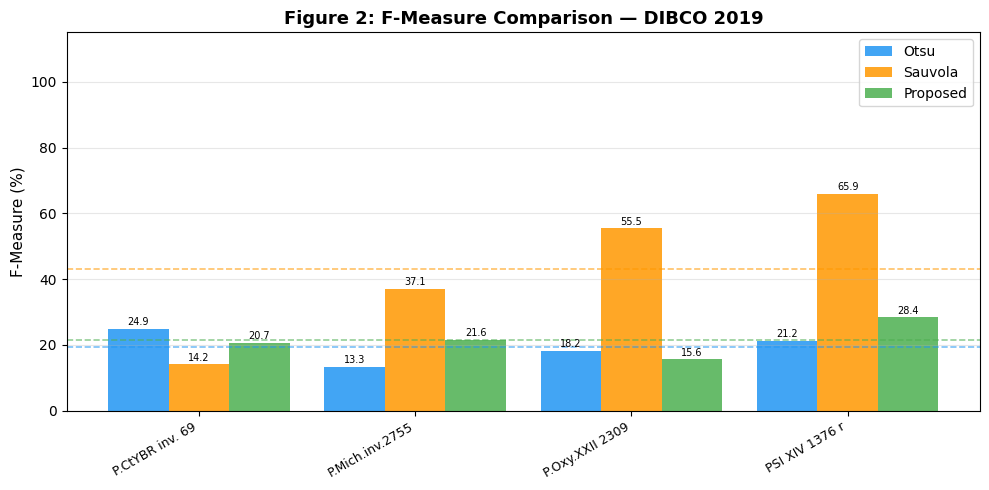

✅ fig2_fmeasure_comparison.png saved


In [9]:
# ── Figure 2: F-measure comparison bar chart ──────────────────────
if all_results:
    names  = list(all_results.keys())
    short_names = [n[:15] for n in names]
    o_vals = [all_results[n]['Otsu']['f_measure']     for n in names]
    s_vals = [all_results[n]['Sauvola']['f_measure']  for n in names]
    p_vals = [all_results[n]['Proposed']['f_measure'] for n in names]

    x = np.arange(len(names))
    w = 0.28

    fig, ax = plt.subplots(figsize=(max(10, len(names)*1.8), 5))
    b1 = ax.bar(x - w,   o_vals, w, label='Otsu',     color='#2196F3', alpha=0.85)
    b2 = ax.bar(x,       s_vals, w, label='Sauvola',  color='#FF9800', alpha=0.85)
    b3 = ax.bar(x + w,   p_vals, w, label='Proposed', color='#4CAF50', alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.5,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=7)

    ax.axhline(np.mean(o_vals), color='#2196F3', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(np.mean(s_vals), color='#FF9800', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(np.mean(p_vals), color='#4CAF50', ls='--', lw=1.2, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('F-Measure (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_title('Figure 2: F-Measure Comparison — DIBCO 2019',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig2_fmeasure_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig2_fmeasure_comparison.png saved')

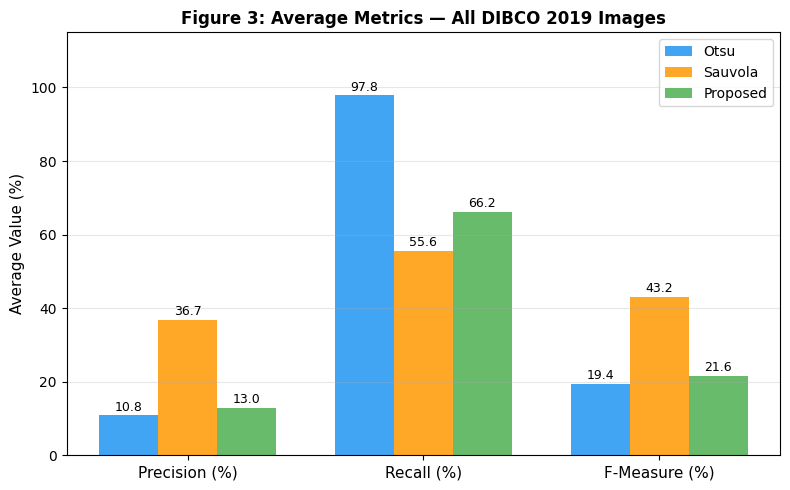

✅ fig3_avg_metrics.png saved


In [10]:
# ── Figure 3: Average Precision / Recall / F-measure summary ─
if all_results:
    metrics_list = ['precision', 'recall', 'f_measure']
    metric_labels = ['Precision (%)', 'Recall (%)', 'F-Measure (%)']

    avgs = {}
    for mname in ['Otsu', 'Sauvola', 'Proposed']:
        avgs[mname] = {
            m: np.mean([all_results[n][mname][m] for n in all_results])
            for m in metrics_list
        }

    x = np.arange(3); w = 0.25
    colors = {'Otsu':'#2196F3','Sauvola':'#FF9800','Proposed':'#4CAF50'}

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (mname, vals) in enumerate(avgs.items()):
        ys = [vals[m] for m in metrics_list]
        bars = ax.bar(x + (i-1)*w, ys, w,
                      label=mname, color=colors[mname], alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Average Value (%)', fontsize=11)
    ax.set_title('Figure 3: Average Metrics — All DIBCO 2019 Images',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig3_avg_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig3_avg_metrics.png saved')

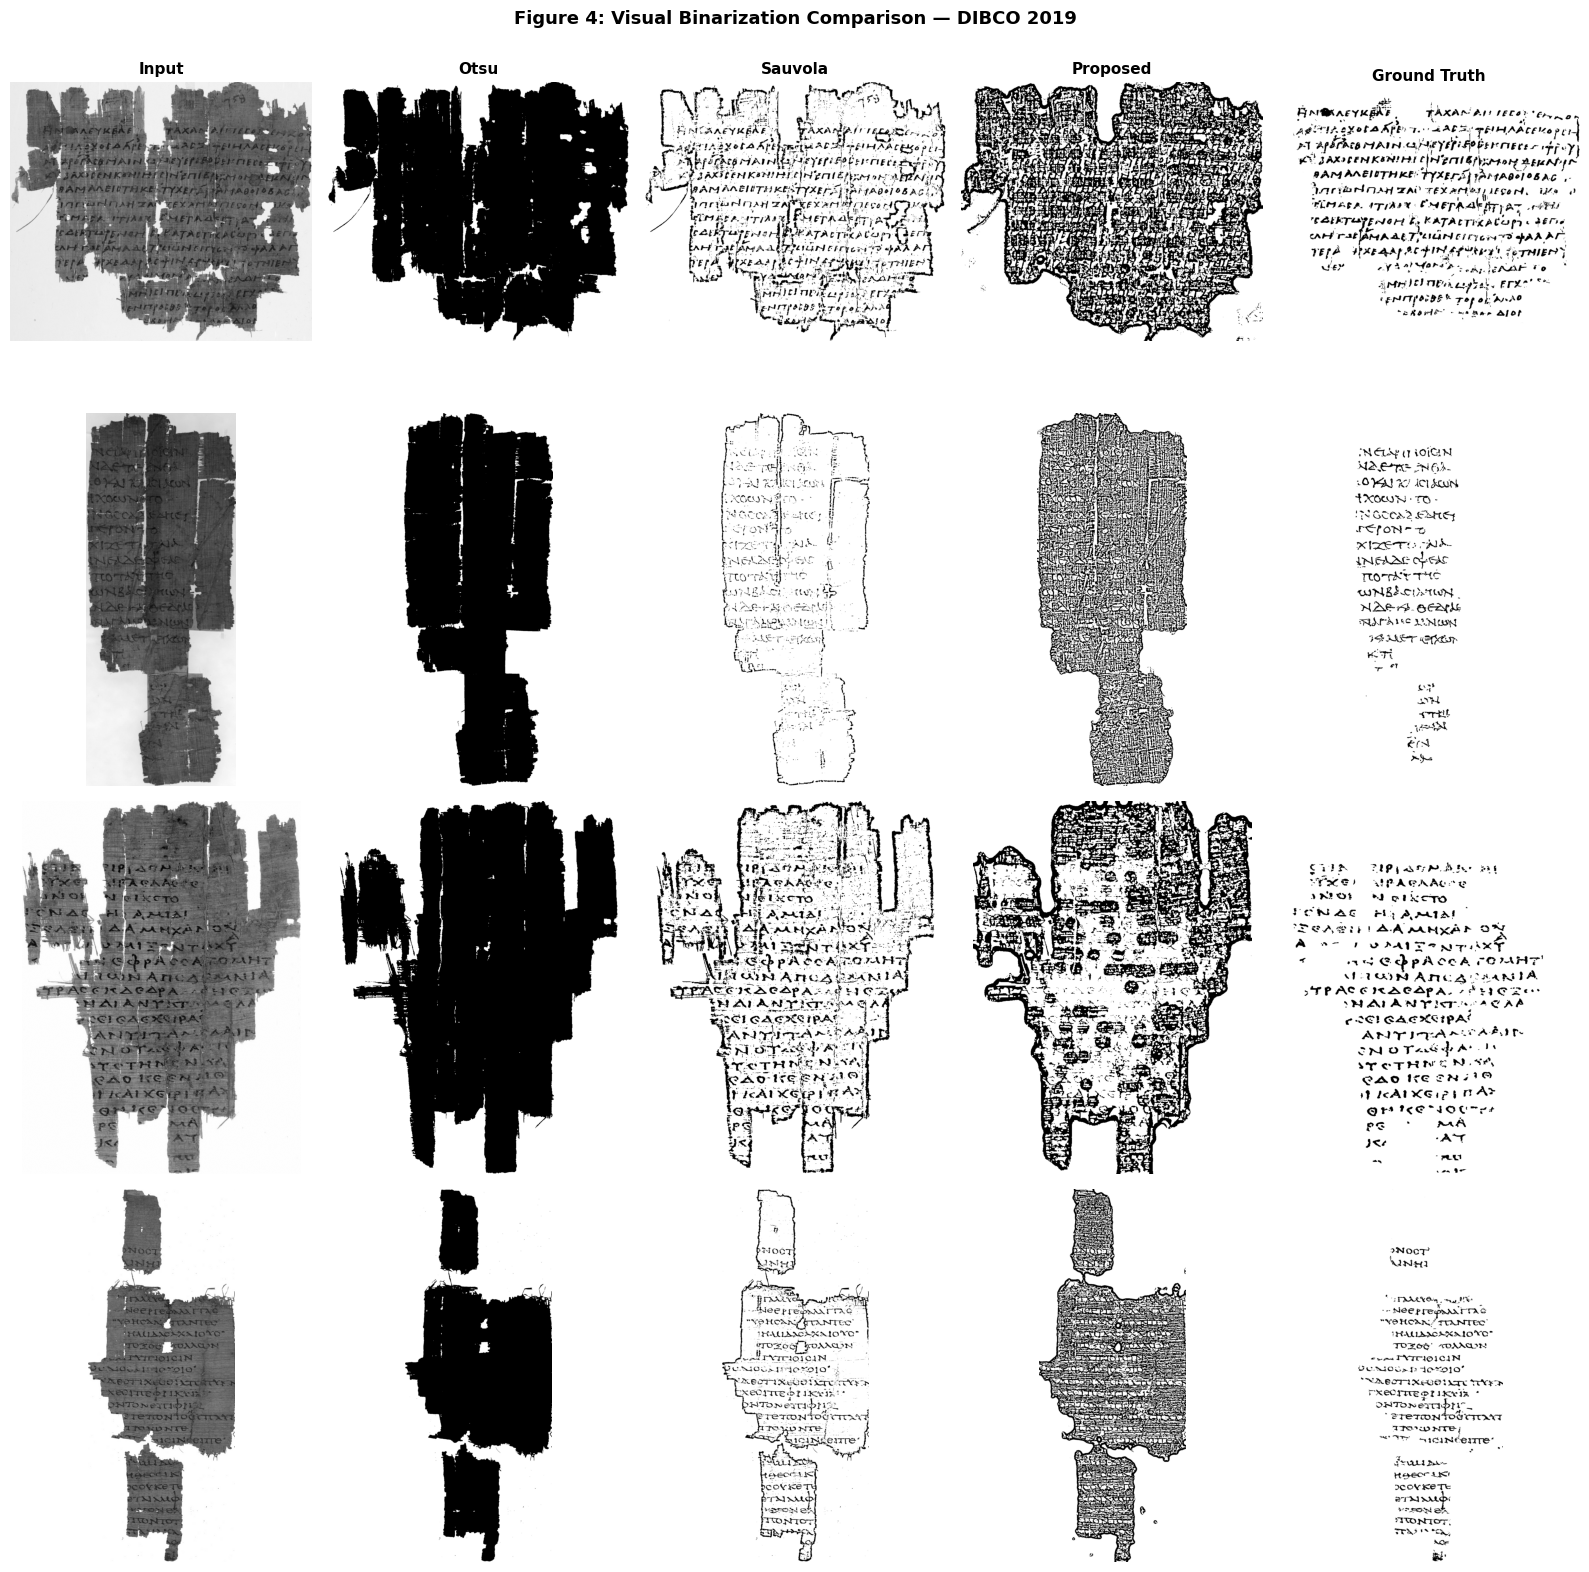

✅ fig4_visual_comparison.png saved


In [11]:
if all_results:
    show_pairs = PAIRS
    fig, axes = plt.subplots(len(show_pairs), 5,
                              figsize=(16, 4*len(show_pairs)))
    if len(show_pairs) == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Input', 'Otsu', 'Sauvola', 'Proposed', 'Ground Truth']

    for row, p in enumerate(show_pairs):
        gray = cv2.imread(p['img'], cv2.IMREAD_GRAYSCALE)
        gt   = cv2.imread(p['gt'],  cv2.IMREAD_GRAYSCALE)
        preds = [
            otsu_binarize(gray),
            sauvola_binarize(gray),
            proposed_binarize(gray),
        ]
        imgs = [gray] + preds + [gt]

        for col, (ax, img) in enumerate(zip(axes[row], imgs)):
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, fontweight='bold')
            if col == 0:
                ax.set_ylabel(p['name'][:20], fontsize=9, rotation=0,
                              labelpad=60, va='center')

    plt.suptitle('Figure 4: Visual Binarization Comparison — DIBCO 2019',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig4_visual_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig4_visual_comparison.png saved')

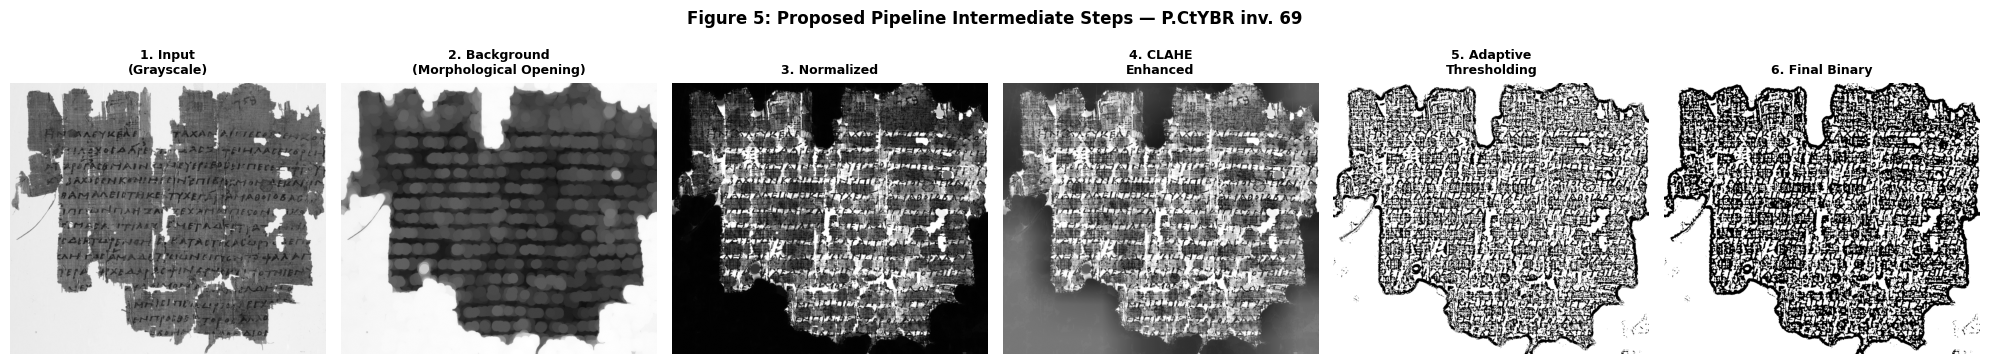

✅ fig5_pipeline_steps.png saved


In [12]:
# ── Figure 5: Pipeline intermediate steps ──────────────────────
if PAIRS:
    gray = cv2.imread(PAIRS[0]['img'], cv2.IMREAD_GRAYSCALE)

    # Calculate intermediate steps
    morph_size = 35
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_size, morph_size))
    background = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    norm = np.clip(gray.astype(np.float32) /
                   (background.astype(np.float32)+1e-6) * 128,
                   0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(norm)
    binary   = cv2.adaptiveThreshold(enhanced, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 41, 5)
    k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    final = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k3)

    step_imgs   = [gray, background, norm, enhanced, binary, final]
    step_titles = [
        '1. Input\n(Grayscale)',
        '2. Background\n(Morphological Opening)',
        '3. Normalized',
        '4. CLAHE\nEnhanced',
        '5. Adaptive\nThresholding',
        '6. Final Binary'
    ]

    fig, axes = plt.subplots(1, 6, figsize=(20, 4))
    for ax, img, t in zip(axes, step_imgs, step_titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(t, fontsize=9, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'Figure 5: Proposed Pipeline Intermediate Steps — {PAIRS[0]["name"]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig5_pipeline_steps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig5_pipeline_steps.png saved')

  morph=15  clip=1.5  F=22.30%  t=61.3ms
  morph=15  clip=2.0  F=21.91%  t=61.1ms
  morph=15  clip=3.0  F=21.41%  t=61.7ms
  morph=25  clip=1.5  F=22.18%  t=81.6ms
  morph=25  clip=2.0  F=21.77%  t=80.9ms
  morph=25  clip=3.0  F=21.25%  t=84.9ms
  morph=35  clip=1.5  F=22.52%  t=111.8ms
  morph=35  clip=2.0  F=22.11%  t=108.7ms
  morph=35  clip=3.0  F=21.57%  t=110.3ms


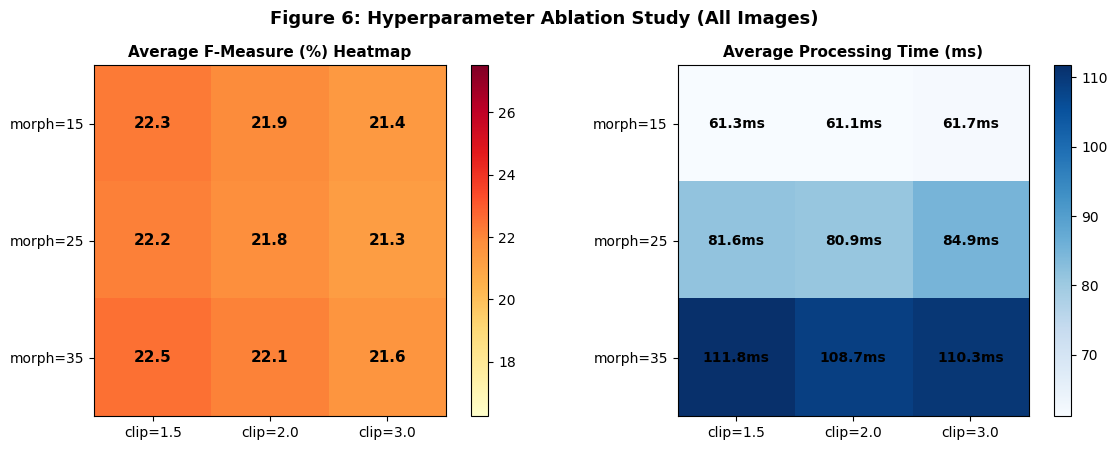

✅ fig6_hyperparameter.png saved

📋 Hyperparameter Table:
  morph   clip   Avg F%   Avg ms
----------------------------------
     15    1.5    22.30     61.3
     15    2.0    21.90     61.1
     15    3.0    21.41     61.7
     25    1.5    22.18     81.6
     25    2.0    21.77     80.9
     25    3.0    21.25     84.9
     35    1.5    22.52    111.8 ★
     35    2.0    22.12    108.7
     35    3.0    21.57    110.3


In [13]:
if not PAIRS:
    print('⚠️  No images!')
else:
    morph_sizes  = [15, 25, 35]
    clahe_clips  = [1.5, 2.0, 3.0]


    test_pairs = PAIRS

    # F-measure average grid
    fmat = np.zeros((len(morph_sizes), len(clahe_clips)))
    tmat = np.zeros_like(fmat)

    hyper_rows = []
    for i, msize in enumerate(morph_sizes):
        for j, clip in enumerate(clahe_clips):
            f_scores, times = [], []
            for p in test_pairs:
                gray = cv2.imread(p['img'], cv2.IMREAD_GRAYSCALE)
                gt   = cv2.imread(p['gt'],  cv2.IMREAD_GRAYSCALE)
                if gray is None: continue
                if gray.shape != gt.shape:
                    gt = cv2.resize(gt, (gray.shape[1], gray.shape[0]),
                                    interpolation=cv2.INTER_NEAREST)
                t0   = time.time()
                pred = proposed_binarize(gray, morph_size=msize, clahe_clip=clip)
                times.append((time.time()-t0)*1000)
                f_scores.append(compute_metrics(pred, gt)['f_measure'])

            avg_f = np.mean(f_scores)
            avg_t = np.mean(times)
            fmat[i, j] = avg_f
            tmat[i, j] = avg_t
            hyper_rows.append({
                'morph_size': msize, 'clahe_clip': clip,
                'avg_f': round(avg_f, 2), 'avg_time_ms': round(avg_t, 1)
            })
            print(f'  morph={msize:>2}  clip={clip}  '
                  f'F={avg_f:.2f}%  t={avg_t:.1f}ms')

    # Heatmap
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    im1 = axes[0].imshow(fmat, cmap='YlOrRd',
                          vmin=max(0, fmat.min()-5), vmax=min(100, fmat.max()+5))
    axes[0].set_xticks(range(len(clahe_clips)))
    axes[0].set_xticklabels([f'clip={c}' for c in clahe_clips])
    axes[0].set_yticks(range(len(morph_sizes)))
    axes[0].set_yticklabels([f'morph={m}' for m in morph_sizes])
    axes[0].set_title('Average F-Measure (%) Heatmap', fontsize=11, fontweight='bold')
    for ii in range(len(morph_sizes)):
        for jj in range(len(clahe_clips)):
            axes[0].text(jj, ii, f'{fmat[ii,jj]:.1f}',
                         ha='center', va='center', fontsize=11, fontweight='bold',
                         color='white' if fmat[ii,jj] > 70 else 'black')
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].imshow(tmat, cmap='Blues')
    axes[1].set_xticks(range(len(clahe_clips)))
    axes[1].set_xticklabels([f'clip={c}' for c in clahe_clips])
    axes[1].set_yticks(range(len(morph_sizes)))
    axes[1].set_yticklabels([f'morph={m}' for m in morph_sizes])
    axes[1].set_title('Average Processing Time (ms)', fontsize=11, fontweight='bold')
    for ii in range(len(morph_sizes)):
        for jj in range(len(clahe_clips)):
            axes[1].text(jj, ii, f'{tmat[ii,jj]:.1f}ms',
                         ha='center', va='center', fontsize=10, fontweight='bold')
    plt.colorbar(im2, ax=axes[1])

    plt.suptitle('Figure 6: Hyperparameter Ablation Study (All Images)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig6_hyperparameter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig6_hyperparameter.png saved')

    # Table
    print('\n📋 Hyperparameter Table:')
    print(f'{"morph":>7} {"clip":>6} {"Avg F%":>8} {"Avg ms":>8}')
    print('-' * 34)
    for r in hyper_rows:
        star = ' ★' if r['avg_f'] == max(rr['avg_f'] for rr in hyper_rows) else ''
        print(f'{r["morph_size"]:>7} {r["clahe_clip"]:>6.1f} '
              f'{r["avg_f"]:>8.2f} {r["avg_time_ms"]:>8.1f}{star}')

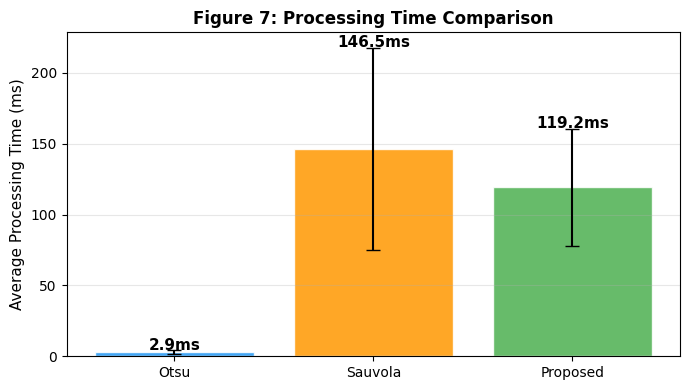

✅ fig7_timing.png saved


In [14]:
if all_results:
    method_times = {m: [] for m in ['Otsu', 'Sauvola', 'Proposed']}
    for name, res in all_results.items():
        for m in method_times:
            method_times[m].append(res[m]['time_ms'])

    fig, ax = plt.subplots(figsize=(7, 4))
    colors_t = {'Otsu': '#2196F3', 'Sauvola': '#FF9800', 'Proposed': '#4CAF50'}
    for mname, times in method_times.items():
        ax.bar(mname, np.mean(times), color=colors_t[mname],
               alpha=0.85, edgecolor='white',
               yerr=np.std(times), capsize=5)
        ax.text(mname, np.mean(times) + np.std(times) + 0.5,
                f'{np.mean(times):.1f}ms', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylabel('Average Processing Time (ms)', fontsize=11)
    ax.set_title('Figure 7: Processing Time Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig7_timing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ fig7_timing.png saved')

In [15]:
# Put all figures and results in a zip
zip_name = 'binarization_results.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    # Figures
    for fn in sorted(os.listdir('.')):
        if fn.startswith('fig') and fn.endswith('.png'):
            zf.write(fn)
            print(f'  + {fn}')
    # JSON metrics
    if os.path.exists('results/metrics.json'):
        zf.write('results/metrics.json', 'metrics.json')
        print('  + metrics.json')

print(f'\n📦 {zip_name} created')
files.download(zip_name)
print('✅ Download started!')

  + fig1_dataset_samples.png
  + fig2_fmeasure_comparison.png
  + fig3_avg_metrics.png
  + fig4_visual_comparison.png
  + fig5_pipeline_steps.png
  + fig6_hyperparameter.png
  + fig7_timing.png
  + metrics.json

📦 binarization_results.zip created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
